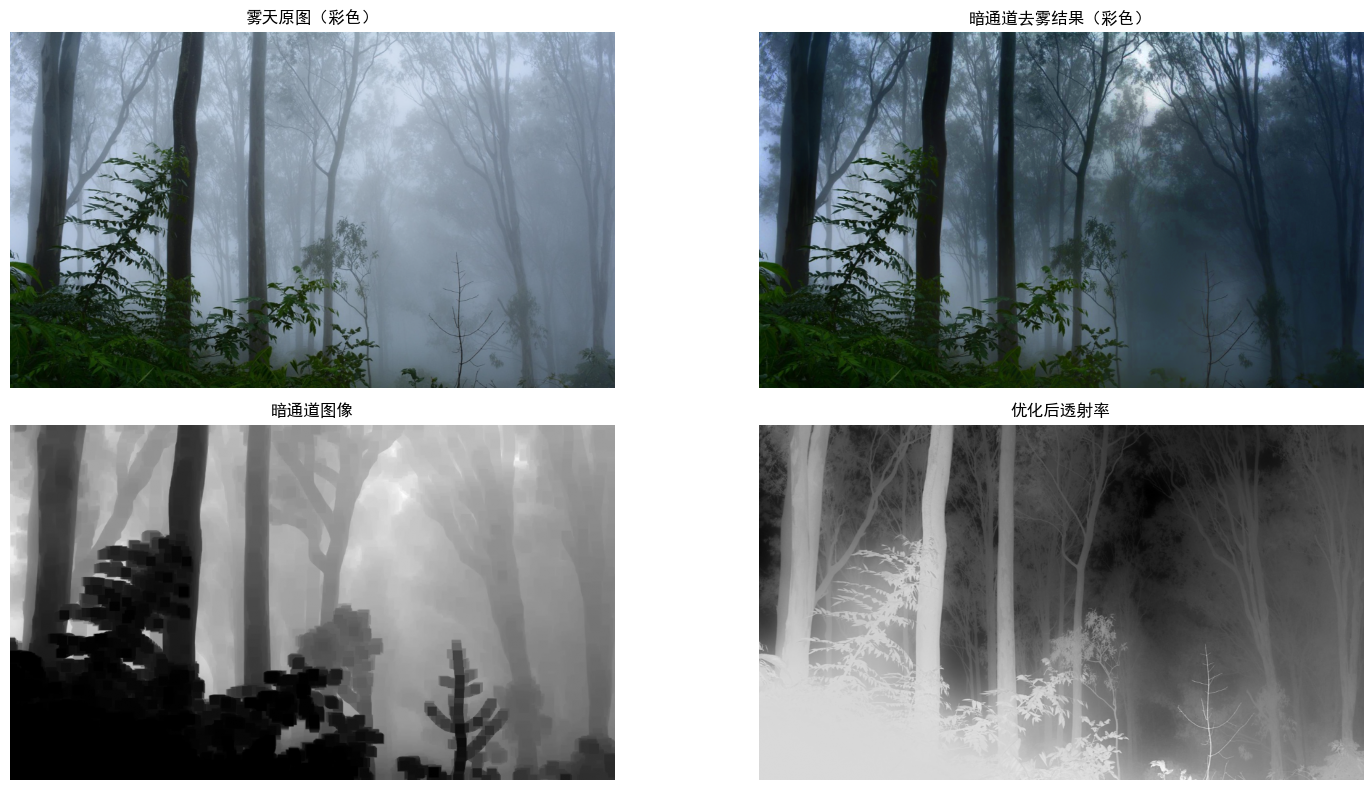

去雾后彩色图形状（高×宽×通道）： (577, 981, 3)
去雾后彩色图数据类型： uint8
去雾后彩色图示例像素值（左上角）： [ 61  95 126]


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 解决中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def dark_channel(img, window_size=15):
    """计算暗通道图像"""
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (window_size, window_size))
    min_channel = cv2.min(cv2.min(img[:, :, 0], img[:, :, 1]), img[:, :, 2])
    dark_img = cv2.erode(min_channel, kernel)
    return dark_img

def estimate_atmospheric_light(img, dark_img):
    """估算大气光A"""
    h, w = img.shape[:2]
    num_pixels = int(h * w * 0.001)
    dark_flat = dark_img.flatten()
    img_flat = img.reshape(-1, 3)
    idx = dark_flat.argsort()[::-1][:num_pixels]
    atmospheric_light = np.mean(img_flat[idx], axis=0)
    return atmospheric_light

def estimate_transmission(img, atmospheric_light, window_size=15, omega=0.95):
    """估算透射率t(x)"""
    norm_img = img / atmospheric_light
    norm_dark = dark_channel(norm_img, window_size)
    transmission = 1 - omega * norm_dark
    return transmission

def guided_filter(img, guide, radius=60, eps=1e-3):
    """引导滤波优化透射率"""
    img_32f = img.astype(np.float32)
    guide_8u = (guide * 255).astype(np.uint8) if guide.max() <= 1 else guide.astype(np.uint8)
    return cv2.ximgproc.guidedFilter(guide=guide_8u, src=img_32f, radius=radius, eps=eps)

def recover_scene(img, atmospheric_light, transmission, t0=0.1):
    """恢复无雾彩色图像"""
    transmission = np.maximum(transmission, t0)
    transmission = np.expand_dims(transmission, axis=2)
    recover_img = (img - atmospheric_light) / transmission + atmospheric_light
    recover_img = np.clip(recover_img, 0, 1)
    recover_img = (recover_img * 255).astype(np.uint8)
    return recover_img

def dark_channel_dehazing(img_path, window_size=15):
    """
    暗通道先验去雾主函数
    :return: original_rgb（原图RGB）, dehazed_rgb（去雾后RGB彩色图）
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError("图像路径错误或文件不存在！")
    original_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_norm = original_rgb.astype(np.float64) / 255.0

    dark_img = dark_channel(img_norm, window_size)
    atmospheric_light = estimate_atmospheric_light(img_norm, dark_img)
    transmission = estimate_transmission(img_norm, atmospheric_light, window_size)
    transmission_refine = guided_filter(transmission, original_rgb[:, :, 0])
    dehazed_rgb = recover_scene(img_norm, atmospheric_light, transmission_refine)

    return original_rgb, dehazed_rgb, dark_img, transmission_refine

# 测试代码
img_path = "foggy_image.png"

try:
    original_rgb, dehazed_rgb, dark_img, transmission = dark_channel_dehazing(img_path)

    plt.figure(figsize=(16, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(original_rgb)
    plt.title("雾天原图（彩色）", fontsize=12)
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(dehazed_rgb)
    plt.title("暗通道去雾结果（彩色）", fontsize=12)
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(dark_img, cmap='gray')
    plt.title("暗通道图像", fontsize=12)
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(transmission, cmap='gray')
    plt.title("优化后透射率", fontsize=12)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("去雾后彩色图形状（高×宽×通道）：", dehazed_rgb.shape)
    print("去雾后彩色图数据类型：", dehazed_rgb.dtype)
    print("去雾后彩色图示例像素值（左上角）：", dehazed_rgb[0, 0, :])

except Exception as e:
    print(f"运行错误：{e}")